# ALK/DIC diagram

In [141]:
import sys
sys.path.insert(0, "roms_marbl_dic/workflows")
from pathlib import Path
from datetime import datetime
import logging

import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm

import carbonate

logging.getLogger().setLevel(logging.WARNING)  # mute roms_tools' INFO logging (e.g. Grid.from_file)

## Typical background state

Loads the precomputed time- and spatial-mean control-run state (temperature, salinity, PO4, SiO3, ALK, DIC), produced by running:

```
sbatch roms_marbl_dic/workflows/compute_typical_state_for_alk_dic_diagram.sh
```

which computes the time mean exactly as `compute_carbonate_sensitivity_from_mean_ctrl.py` does, then averages spatially to a single representative point.

In [142]:
typical_state_file = Path("roms_marbl_dic/expCTRL/BETA/typical_state_for_alk_dic_diagram.nc")
ds_typical = xr.open_dataset(typical_state_file)

temp_typical = float(ds_typical["temp"])
salt_typical = float(ds_typical["salt"])
po4_typical = float(ds_typical["PO4"])
sio3_typical = float(ds_typical["SiO3"])
alk_typical = float(ds_typical["ALK_ALT_CO2"])  # mmol/m3
dic_typical = float(ds_typical["DIC_ALT_CO2"])  # mmol/m3

print(f"Typical temperature: {temp_typical:.2f} degC")
print(f"Typical salinity:    {salt_typical:.2f} psu")
print(f"Typical PO4:         {po4_typical:.4f} mmol/m3")
print(f"Typical SiO3:        {sio3_typical:.4f} mmol/m3")
print(f"Typical ALK:         {alk_typical:.1f} mmol/m3")
print(f"Typical DIC:         {dic_typical:.1f} mmol/m3")

Typical temperature: 21.88 degC
Typical salinity:    34.50 psu
Typical PO4:         0.5167 mmol/m3
Typical SiO3:        3.1681 mmol/m3
Typical ALK:         2301.6 mmol/m3
Typical DIC:         2007.4 mmol/m3


## Compute $\beta$ and $\eta$ on an ALK-DIC grid

Build a 2-D grid of ALK and DIC values around the typical background state, and evaluate the carbonate sensitivities from `carbonate.compute_sensitivities` at fixed typical temperature, salinity, phosphate, and silicate.

In [143]:
n_points = 750

#alk_vals = np.linspace(2000, 2700, n_points)  # mmol/m3
#dic_vals = np.linspace(1700, 2300, n_points)  # mmol/m3
alk_vals = np.linspace(2000, 2400, n_points)  # mmol/m3
dic_vals = np.linspace(1750, 2250, n_points)  # mmol/m3

alk_grid, dic_grid = np.meshgrid(alk_vals, dic_vals)

ds_grid = xr.Dataset(
    {
        "ALK_ALT_CO2": (("dic", "alk"), alk_grid),  # mmol/m3
        "DIC_ALT_CO2": (("dic", "alk"), dic_grid),  # mmol/m3
    },
    coords={"alk": alk_vals, "dic": dic_vals},
)

beta, eta = carbonate.compute_sensitivities(ds_grid, ds_typical, "ALK_ALT_CO2", "DIC_ALT_CO2")

In [144]:
def coverage_histogram(alk_field, dic_field, bins=100):
    """2-D histogram of (alk_field, dic_field) on the notebook's ALK-DIC grid, for contouring the occupied region."""
    hist, alk_edges, dic_edges = np.histogram2d(
        alk_field, dic_field, bins=bins,
        range=[[alk_vals.min(), alk_vals.max()], [dic_vals.min(), dic_vals.max()]],
    )
    alk_centers = 0.5 * (alk_edges[:-1] + alk_edges[1:])
    dic_centers = 0.5 * (dic_edges[:-1] + dic_edges[1:])
    return alk_centers, dic_centers, hist


def add_coverage_contour(ax, alk_centers, dic_centers, hist, color, label, lw=1.5):
    ax.contour(alk_centers, dic_centers, hist.T, levels=[0.5], colors=color,
               linestyles="-", linewidths=lw)
    ax.plot([], [], color=color, linestyle="-", lw=lw, label=label)


def _nice_step(step):
    """Round a step size up to a human-friendly 1/2/5 * 10^k value."""
    magnitude = 10 ** np.floor(np.log10(step))
    residual = step / magnitude
    nice = 10 if residual > 5 else 5 if residual > 2 else 2 if residual > 1 else 1
    return nice * magnitude


def nice_contour_levels(data, n=50):
    """`n` evenly spaced, round-number contour levels spanning data's actual min-max range."""
    vmin, vmax = np.nanmin(data), np.nanmax(data)
    step = _nice_step((vmax - vmin) / (n - 1))
    vmin_rounded = np.floor(vmin / step) * step
    return vmin_rounded + step * np.arange(n)

## Region covered by the Pacific mean state

Use the time-mean (not spatially averaged) ALK and DIC fields to outline the region of ALK-DIC space actually spanned by the Pacific domain.

In [145]:
alk_field = ds_typical["ALK_ALT_CO2_field"].values.ravel()  # mmol/m3
dic_field = ds_typical["DIC_ALT_CO2_field"].values.ravel()  # mmol/m3
valid = np.isfinite(alk_field) & np.isfinite(dic_field)
alk_field = alk_field[valid]
dic_field = dic_field[valid]

alk_centers, dic_centers, coverage_hist = coverage_histogram(alk_field, dic_field)

## Plot ALK-DIC diagram, optionally overlaying a truth experiment

`plot_alk_dic_diagram(date=None, exp=None, scenario=None, use_ctrl_snapshot=False)` draws the $\beta$/$\eta$ panels with the Pacific-state extent. Pass `date`, `exp`, and `scenario` (`"DOR"` for `roms_marbl_dic` or `"OAE"` for `roms_marbl_alk`) to additionally outline the ALK-DIC region covered by that single-date truth-experiment snapshot, via `carbonate.load_experiment_alk_dic`. Pass `scenario=["DOR", "OAE"]` to overlay both scenarios for the same `exp`/`date` on top of the control run at once, each in its own color. By default the Pacific-state extent shown is the 2000-2001 time-mean control state; set `use_ctrl_snapshot=True` to instead show the control run's own snapshot on `date` (via `carbonate.load_ctrl_alk_dic`), for an apples-to-apples comparison against the truth experiment on the same day. Call the function in consecutive cells to compare several experiments/dates.

In [146]:
scenarios = {
    "dor": {
        "marbl_dir": "roms_marbl_dic",
        "ctrl_subdir": "OUTPUT_dor",
        "title": "DOR",
        "exps": {
            "JP10": {"label": r"\mathrm{J10}\!\ominus"},
            "JP7":  {"label": r"\mathrm{J100}\!\ominus"},
            "JP8":  {"label": r"\mathrm{J1000}\!\ominus"},
            "VI10": {"label": r"\mathrm{V10}\!\ominus"},
            "VI7":  {"label": r"\mathrm{V100}\!\ominus"},
            "VI8":  {"label": r"\mathrm{V1000}\!\ominus"},
            "BC10": {"label": r"\mathrm{B10}\!\ominus"},
            "BC7":  {"label": r"\mathrm{B100}\!\ominus"},
            "BC8":  {"label": r"\mathrm{B1000}\!\ominus"},
            "EC10": {"label": r"\mathrm{E10}\!\ominus"},
            "EC7":  {"label": r"\mathrm{E100}\!\ominus"},
            "EC8":  {"label": r"\mathrm{E1000}\!\ominus"},
        },
    },
    "oae": {
        "marbl_dir": "roms_marbl_alk",
        "ctrl_subdir": "OUTPUT_oae_perlmutter",
        "title": "OAE",
        "exps": {
            "JP10": {"label": r"\mathrm{J10}\!\oplus"},
            "JP7":  {"label": r"\mathrm{J100}\!\oplus"},
            "JP8":  {"label": r"\mathrm{J1000}\!\oplus"},
            "VI10": {"label": r"\mathrm{V10}\!\oplus"},
            "VI7":  {"label": r"\mathrm{V100}\!\oplus"},
            "VI8":  {"label": r"\mathrm{V1000}\!\oplus"},
            "BC10": {"label": r"\mathrm{B10}\!\oplus"},
            "BC7":  {"label": r"\mathrm{B100}\!\oplus"},
            "BC8":  {"label": r"\mathrm{B1000}\!\oplus"},
            "EC10": {"label": r"\mathrm{E10}\!\oplus"},
            "EC7":  {"label": r"\mathrm{E100}\!\oplus"},
            "EC8":  {"label": r"\mathrm{E1000}\!\oplus"},
        },
    },
}

In [153]:
def plot_alk_dic_diagram(date=None, exp=None, scenario=None, use_ctrl_snapshot=True, figsize=(8.5, 4), panel_labels=["a", "b"], show_date=False, show_pacific_extent=True):
    if show_pacific_extent:
        if use_ctrl_snapshot:
            if date is None:
                raise ValueError("date must be given when use_ctrl_snapshot=True")
            alk_pac, dic_pac = carbonate.load_ctrl_alk_dic(date)
            alk_centers_pac, dic_centers_pac, coverage_hist_pac = coverage_histogram(alk_pac, dic_pac)
            pac_label = f"control run"
        else:
            alk_centers_pac, dic_centers_pac, coverage_hist_pac = alk_centers, dic_centers, coverage_hist
            pac_label = "Pacific mean-state extent"

    # scenario may be a single scenario name or a list of scenarios (e.g. ["DOR", "OAE"]) to overlay together
    scenario_list = [scenario] if isinstance(scenario, str) else scenario or []
    # separate colors per panel so each exp's line stays legible against both the inferno and viridis backgrounds
    exp_colors = {
        "dor": {"beta": "#b2df8a", "eta": "#fb9a99"},
        "oae": {"beta": "#33a02c", "eta": "#e31a1c"},
    }

    exp_overlays = []
    if date is not None:
        date_str = f"{date[:4]}-{date[4:6]}-{date[6:8]}" if len(date) == 8 and date.isdigit() else str(date)
        for scen in scenario_list:
            alk_exp, dic_exp = carbonate.load_experiment_alk_dic(date, exp, scen)
            alk_centers_exp, dic_centers_exp, coverage_hist_exp = coverage_histogram(alk_exp, dic_exp)
            exp_overlays.append({
                "alk_centers": alk_centers_exp,
                "dic_centers": dic_centers_exp,
                "hist": coverage_hist_exp,
                "colors": exp_colors[scen.lower()],
                "label": f"${scenarios[scen.lower()]['exps'][exp]['label']}$",
            })

    fig, axs = plt.subplots(1, 2, figsize=figsize)
    
    #cbar_kwargs = dict(orientation="vertical", location="right", fraction=0.04, pad=0.05)
    cbar_kwargs = dict(orientation="horizontal", location="bottom", fraction=0.04, pad=0.2)

    n_legend_cols = len(scenario_list) + (1 if show_pacific_extent else 0)
    legend_kwargs = dict(loc="upper center", bbox_to_anchor=(0.5, -0.2), ncol=max(1, n_legend_cols), framealpha=1, facecolor="#d9d9d9")

    def _raise_clabel_texts(clabel_texts):
        # Contour-label numbers should stay legible: always draw on top of the coverage
        # contours added afterward (e.g. the experiment's outline), and never get clipped
        # off when a label lands right at the axes' top/side edge.
        for txt in clabel_texts:
            txt.set_zorder(10)
            txt.set_clip_on(False)

    def _manual_clabel_fixed(cs, x_disp, y_disp, inline=True, inline_spacing=5):
        """Equivalent to ContourSet.add_label_near(), but works around a matplotlib bug:
        when clabel() is called with `levels=` restricted to a subset (as we do below, to
        relocate just one label), add_label_near() indexes labelLevelList/labelCValueList
        with the raw index into ALL of the ContourSet's levels instead of the position
        within the restricted subset, raising IndexError. `cs.clabel(levels=[lvl],
        manual=[])`  must be called first to set up cs's label bookkeeping for that one
        level (adds no label itself, since manual=[] is empty).
        """
        idx_level_min, idx_vtx_min, proj = cs._find_nearest_contour((x_disp, y_disp), cs.labelIndiceList)
        path = cs._paths[idx_level_min]
        level = cs.labelIndiceList.index(idx_level_min)
        label_width = cs._get_nth_label_width(level)
        rotation, path = cs._split_path_and_get_label_rotation(
            path, idx_vtx_min, proj, label_width, inline_spacing)
        cs.add_label(*proj, rotation, cs.labelLevelList[level], cs.labelCValueList[level])
        if inline:
            cs._paths[idx_level_min] = path

    def _clabel_with_relocations(ax, cs, field, levels, fmt, fontsize, moves=None):
        """Like ax.clabel(cs, levels=levels, inline=True, fmt=fmt, fontsize=fontsize), but
        any level whose formatted text matches a key in `moves` (dict: label text -> (dx, dy)
        offset in data units) is shifted by that offset from its default auto-placed spot.

        The relocated label is placed via clabel's manual-labeling machinery, restricted to
        just that one level (so it can't accidentally snap to a neighboring contour line),
        rather than by just moving the Text object -- so the underlying contour line's
        inline gap moves with it too, instead of leaving the dashed line running straight
        through the relocated label.
        """
        moves = moves or {}
        levels = list(levels)
        auto_levels = [lvl for lvl in levels if (fmt % lvl) not in moves]
        move_levels = [lvl for lvl in levels if (fmt % lvl) in moves]

        texts = list(ax.clabel(cs, levels=auto_levels, inline=True, fontsize=fontsize, fmt=fmt)) if auto_levels else []

        for lvl in move_levels:
            dx, dy = moves[fmt % lvl]
            # Throwaway, invisible duplicate of just this level, purely to find where
            # clabel would auto-place its label by default, so we can offset from there.
            tmp_cs = ax.contour(alk_grid, dic_grid, field, levels=[lvl], colors="none", linewidths=0)
            tmp_text = ax.clabel(tmp_cs, levels=[lvl], inline=True, fontsize=fontsize, fmt=fmt)
            x, y = tmp_text[0].get_position()
            tmp_cs.remove()

            # Set up cs's label bookkeeping for just this level (adds no label yet), then
            # place it manually at the offset position via the bug-fixed helper above.
            cs.clabel(levels=[lvl], inline=True, fontsize=fontsize, fmt=fmt, manual=[])
            n_before = len(cs.labelTexts)
            x_disp, y_disp = ax.transData.transform((x + dx, y + dy))
            _manual_clabel_fixed(cs, x_disp, y_disp, inline=True)
            texts.extend(cs.labelTexts[n_before:])

        return texts

    ax = axs[0]
    cf = ax.pcolormesh(alk_grid, dic_grid, beta, cmap="inferno")
    if show_pacific_extent:
        add_coverage_contour(ax, alk_centers_pac, dic_centers_pac, coverage_hist_pac, color="gray", lw=2,
                              label=pac_label)
    for overlay in exp_overlays:
        add_coverage_contour(ax, overlay["alk_centers"], overlay["dic_centers"], overlay["hist"],
                              color=overlay["colors"]["beta"], label=overlay["label"])
        
    levels = nice_contour_levels(beta, n=25)
    cs = ax.contour(alk_grid, dic_grid, beta, levels=levels, colors="white", linestyles="--", linewidths=0.7)
    # "5" sits right on top of the coverage contour there -- nudge it up and to the right a bit.
    #clabel_texts = _clabel_with_relocations(ax, cs, beta, levels[1::3], "%.0f", 9, moves={"5": (60, 60)})
    clabel_texts = _clabel_with_relocations(ax, cs, beta, levels[1::3], "%.0f", 9)
    _raise_clabel_texts(clabel_texts)


    fig.colorbar(cf, ax=ax, **cbar_kwargs, label=r"$\beta$")

    title = rf"({panel_labels[0]}) $\beta(\mathrm{{ALK}}, \mathrm{{DIC}})$"
    if show_date:
        title = f"{title} ({date_str})"
    ax.set_title(title)

    ax = axs[1]
    cf = ax.pcolormesh(alk_grid, dic_grid, eta, cmap="viridis")
    if show_pacific_extent:
        add_coverage_contour(ax, alk_centers_pac, dic_centers_pac, coverage_hist_pac, color="gray", lw=2,
                              label=pac_label)
    for overlay in exp_overlays:
        add_coverage_contour(ax, overlay["alk_centers"], overlay["dic_centers"], overlay["hist"],
                              color=overlay["colors"]["eta"], label=overlay["label"])
        
    levels = nice_contour_levels(eta, 25)
    cs = ax.contour(alk_grid, dic_grid, eta, levels=levels, colors="black", linestyles="--", linewidths=0.7)
    # "0.96" sits right on top of the coverage contour there -- nudge it down and to the left a bit.
    #clabel_texts = _clabel_with_relocations(ax, cs, eta, levels[1::5], "%.2f", 9, moves={"0.96": (-5, -5)})
    clabel_texts = _clabel_with_relocations(ax, cs, eta, levels[1::5], "%.2f", 9)
    _raise_clabel_texts(clabel_texts)


    fig.colorbar(cf, ax=ax, **cbar_kwargs, label=r"$\eta$")
    
    title = rf"({panel_labels[1]}) $\eta(\mathrm{{ALK}}, \mathrm{{DIC}})$"
    if show_date:
        title = f"{title} ({date_str})"
    ax.set_title(title)

    # Schematic intervention arrows starting from the midpoint of the displayed ALK-DIC grid.
    # Values from model experiments representing equal CDR:
    #   OAE: ΔALK = 169, ΔDIC = +43.5 mmol/m³ (along constant-pCO2 isoline)
    #   DOR: ΔDIC = -124 mmol/m³ (straight down, ALK unchanged)
    _alk_mid  = 0.5 * (alk_vals[0] + alk_vals[-1])
    _dic_mid  = 0.5 * (dic_vals[0] + dic_vals[-1])

    _dalk_oae =  169   # mmol/m³
    _ddic_oae =   43.5 # mmol/m³
    _ddic_dor = -124   # mmol/m³

    for _ax, _col in zip(axs, ["white", "white"]):
        _arrow_kw = dict(arrowstyle="-|>", color=_col, lw=2, mutation_scale=14)
        _text_kw  = dict(color=_col, fontsize=9, fontweight="bold", zorder=6,
                         bbox=dict(boxstyle="round,pad=0.15", fc="none", ec="none"))

        # dot at the shared origin
        _ax.plot(_alk_mid, _dic_mid, "o", color=_col, ms=5, zorder=6)

        # DOR arrow (straight down)
        _ax.annotate(
            "", xy=(_alk_mid, _dic_mid + _ddic_dor), xytext=(_alk_mid, _dic_mid),
            arrowprops=dict(**_arrow_kw), zorder=6,
        )
        _ax.text(_alk_mid + 6, _dic_mid + _ddic_dor / 2,
                 "DOR", va="center", ha="left", **_text_kw)

        # OAE arrow (right and up along constant-pCO2 isoline)
        _ax.annotate(
            "", xy=(_alk_mid + _dalk_oae, _dic_mid + _ddic_oae), xytext=(_alk_mid, _dic_mid),
            arrowprops=dict(**_arrow_kw), zorder=6,
        )
        _ax.text(_alk_mid + _dalk_oae / 2 - 8, _dic_mid + _ddic_oae / 2 + 8,
                 "OAE", va="bottom", ha="center", **_text_kw)

    for ax in axs:
        #ax.legend(**legend_kwargs)
        ax.set_xlabel(r"ALK [mmol m$^{-3}$]")
        ax.set_ylabel(r"DIC [mmol m$^{-3}$]")
        
    #if date:
    #    fig.suptitle(datetime.strptime(date, "%Y%m%d").strftime("%B %-d, %Y"))

    plt.tight_layout()
    return fig

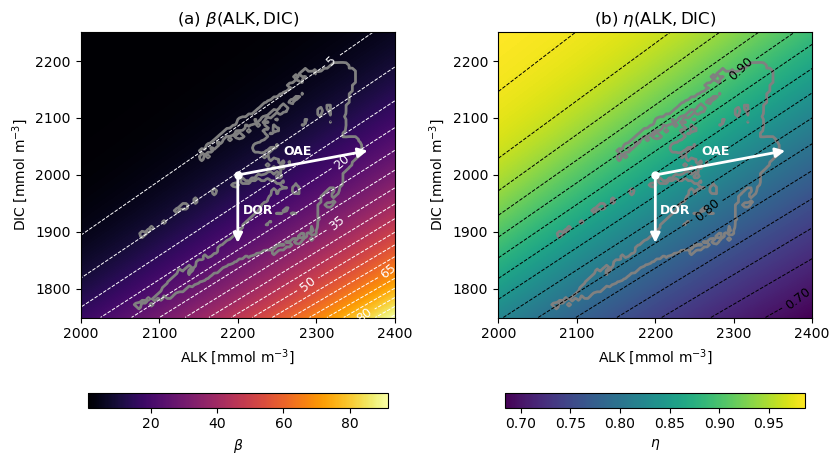

In [154]:
fig = plot_alk_dic_diagram(use_ctrl_snapshot=False, figsize=(8.5, 4.75))

In [155]:
fig.savefig("figures/alk_dic_diagram.png", dpi=300, bbox_inches="tight")

## Japan

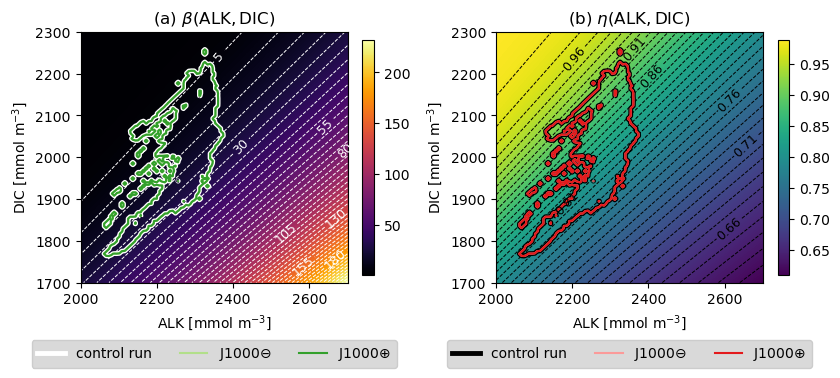

In [9]:
fig = plot_alk_dic_diagram("20000701", "JP8", scenario=["DOR", "OAE"])

In [10]:
fig.savefig("figures/alk_dic_diagram_JP1000.png", dpi=300, bbox_inches="tight")

## Vancouver Island

In [10]:
date = "20000701"

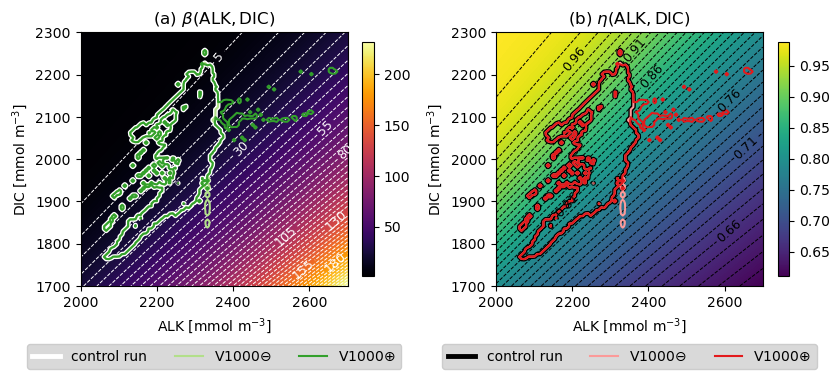

In [11]:
fig = plot_alk_dic_diagram(date, "VI8", scenario=["DOR", "OAE"])

In [13]:
fig.savefig("figures/alk_dic_diagram_VI1000.png", dpi=300, bbox_inches="tight")

In [14]:
date = "20000201"

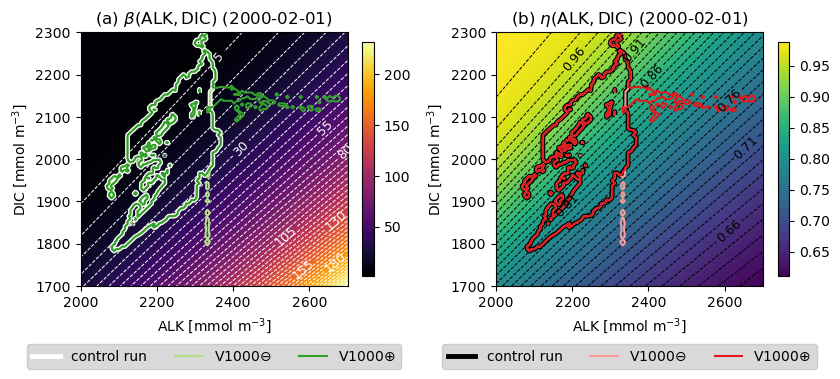

In [15]:
fig = plot_alk_dic_diagram(date, "VI8", scenario=["DOR", "OAE"], show_date=True)

In [16]:
fig.savefig(f"figures/alk_dic_diagram_VI1000_{date}.png", dpi=300, bbox_inches="tight")

In [17]:
date = "20001231"

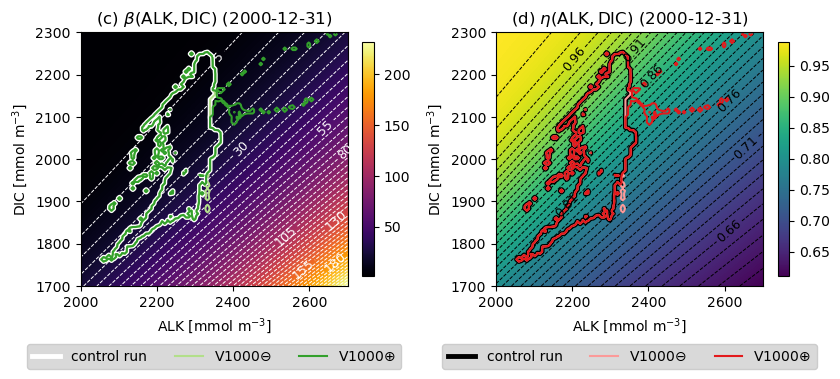

In [18]:
fig = plot_alk_dic_diagram(date, "VI8", scenario=["DOR", "OAE"], panel_labels=["c", "d"], show_date=True)

In [19]:
fig.savefig(f"figures/alk_dic_diagram_VI1000_{date}.png", dpi=300, bbox_inches="tight")

In [20]:
date = "20011231"

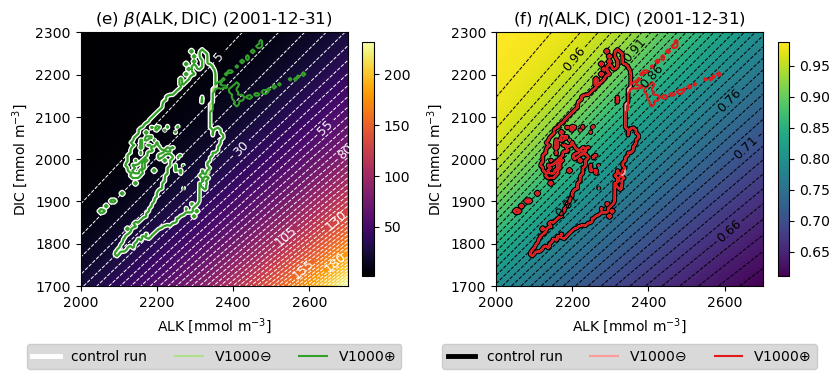

In [21]:
fig = plot_alk_dic_diagram(date, "VI8", scenario=["DOR", "OAE"], panel_labels=["e", "f"], show_date=True)

In [22]:
fig.savefig(f"figures/alk_dic_diagram_VI1000_{date}.png", dpi=300, bbox_inches="tight")

## Baja California

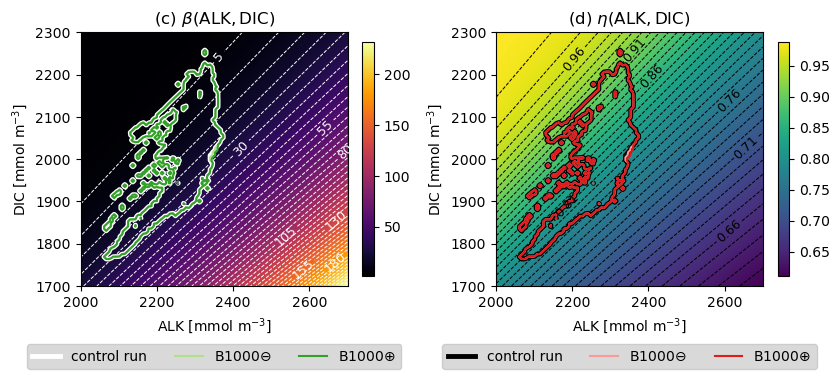

In [88]:
fig = plot_alk_dic_diagram("20000701", "BC8", scenario=["DOR", "OAE"], panel_labels=("c", "d"))

In [89]:
fig.savefig("figures/alk_dic_diagram_BC1000.png", dpi=300, bbox_inches="tight")

## Ecuador

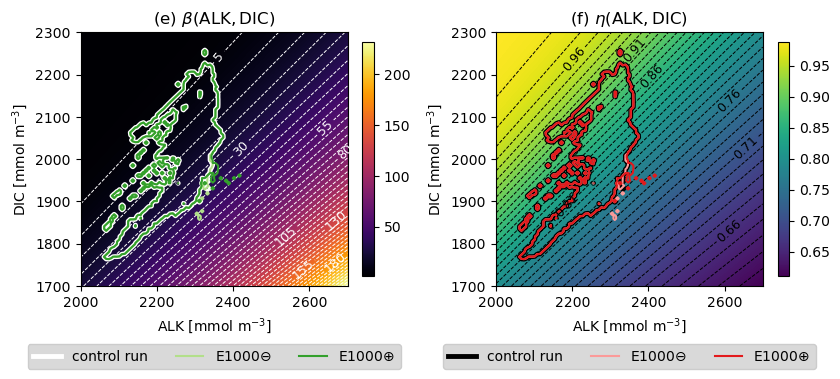

In [90]:
fig = plot_alk_dic_diagram("20000701", "EC8", scenario=["DOR", "OAE"], panel_labels=("e", "f"))

In [91]:
fig.savefig("figures/alk_dic_diagram_EC1000.png", dpi=300, bbox_inches="tight")